In [2]:
# ============================================================
# CART Regression Example: Predicting Tips
# ============================================================

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# 1. Load dataset
tips = sns.load_dataset("tips")

# Features (X) and target (y)
X = pd.get_dummies(tips[["total_bill", "sex", "smoker", "day", "time", "size"]], drop_first=True)
y = tips["tip"]




In [4]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



In [6]:
# 3. Train CART regressor
tree_reg = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [9]:
# 4. Predict
y_pred = tree_reg.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Mean Squared Error: 1.0485042863641545
R² Score: 0.20458740295914313


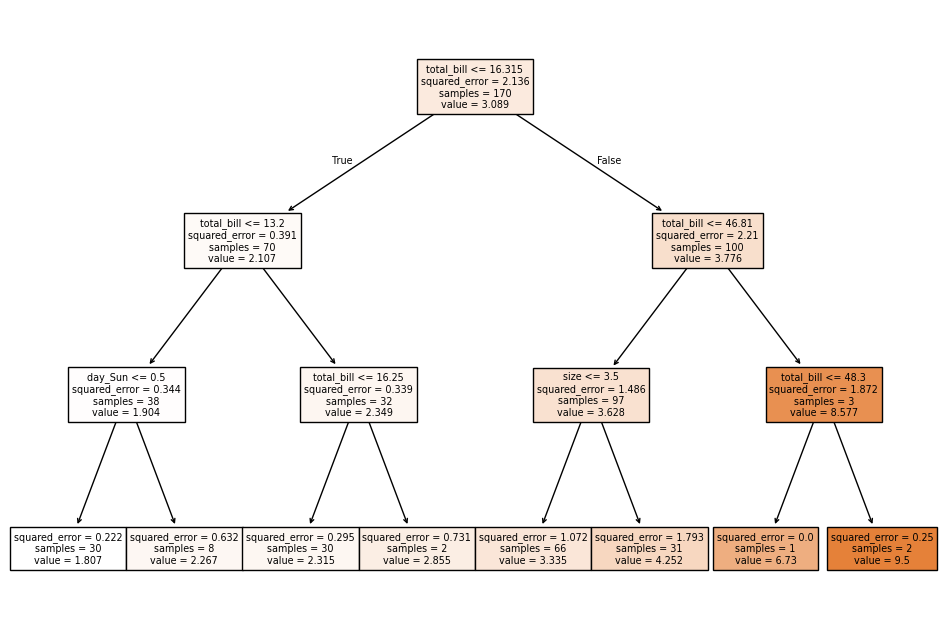

In [10]:
# 5. Visualize the regression tree
plt.figure(figsize=(12,8))
plot_tree(tree_reg, feature_names=X.columns, filled=True)
plt.show()

In [11]:
# Alternative view
from sklearn.tree import export_text

tree_rules = export_text(tree_reg, feature_names=list(X.columns))
print(tree_rules)

|--- total_bill <= 16.31
|   |--- total_bill <= 13.20
|   |   |--- day_Sun <= 0.50
|   |   |   |--- value: [1.81]
|   |   |--- day_Sun >  0.50
|   |   |   |--- value: [2.27]
|   |--- total_bill >  13.20
|   |   |--- total_bill <= 16.25
|   |   |   |--- value: [2.31]
|   |   |--- total_bill >  16.25
|   |   |   |--- value: [2.85]
|--- total_bill >  16.31
|   |--- total_bill <= 46.81
|   |   |--- size <= 3.50
|   |   |   |--- value: [3.33]
|   |   |--- size >  3.50
|   |   |   |--- value: [4.25]
|   |--- total_bill >  46.81
|   |   |--- total_bill <= 48.30
|   |   |   |--- value: [6.73]
|   |   |--- total_bill >  48.30
|   |   |   |--- value: [9.50]



In [12]:
# 6. Make predictions on new data

# Create 5 random examples
new_data = pd.DataFrame({
    'total_bill': [25.50, 15.00, 35.00, 10.00, 40.00],
    'size': [3, 2, 4, 1, 5],
    'sex_Female': [True, False, True, False, True],
    'smoker_No': [False, True, True, False, False],
    'day_Fri': [False, True, False, False, True],
    'day_Sat': [True, False, False, True, False],
    'day_Sun': [False, False, True, False, False],
    'time_Dinner': [True, False, True, False, True]
})

# Ensure the new data has the same columns as the training data
new_data = new_data.reindex(columns=X.columns, fill_value=False)


# Make predictions
predictions = tree_reg.predict(new_data)

# Display the predictions
print("Predictions for new data:")
print(predictions)

Predictions for new data:
[3.33454545 2.315      4.25193548 1.80666667 4.25193548]


In [13]:
# Create a DataFrame with the new data and predictions
predictions_df = new_data.copy()
predictions_df['predicted_tip'] = predictions

# Display the DataFrame
print("\nNew data with predicted tips:")
print(predictions_df)


New data with predicted tips:
   total_bill  size  sex_Female  smoker_No  day_Fri  day_Sat  day_Sun  \
0        25.5     3        True      False    False     True    False   
1        15.0     2       False       True     True    False    False   
2        35.0     4        True       True    False    False     True   
3        10.0     1       False      False    False     True    False   
4        40.0     5        True      False     True    False    False   

   time_Dinner  predicted_tip  
0         True       3.334545  
1        False       2.315000  
2         True       4.251935  
3        False       1.806667  
4         True       4.251935  
